# Benchmark Comparison

This notebook compares the two resume NER benchmark models:

- **Benchmark A:** `deberta-v3-base`
- **Benchmark B:** `roberta-base`

The comparison uses the same final evaluation metrics:

- Precision
- Recall
- F1-score
- Accuracy

**F1-score is used as the primary metric for model selection** because it balances precision and recall for Named Entity Recognition.


In [11]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"

A_JSON = os.path.join(RESULTS_DIR, "benchmark_a.json")
B_JSON = os.path.join(RESULTS_DIR, "benchmark_b.json")
A_ENTITY_CSV = os.path.join(RESULTS_DIR, "benchmark_a_per_entity.csv")

print("Benchmark A JSON exists:", os.path.exists(A_JSON))
print("Benchmark B JSON exists:", os.path.exists(B_JSON))
print("Benchmark A per-entity CSV exists:", os.path.exists(A_ENTITY_CSV))


Benchmark A JSON exists: True
Benchmark B JSON exists: True
Benchmark A per-entity CSV exists: True


## 1. Load Benchmark Results

In [12]:
with open(A_JSON, "r", encoding="utf-8") as f:
    benchmark_a = json.load(f)

with open(B_JSON, "r", encoding="utf-8") as f:
    benchmark_b = json.load(f)

print("Benchmark A:", benchmark_a["model"])
print("Benchmark B:", benchmark_b["model"])


Benchmark A: microsoft/deberta-v3-base
Benchmark B: roberta-base


## 2. Overall Benchmark Comparison

In [3]:
overall_comparison = pd.DataFrame(
    [
        {
            "Model": "DeBERTa-v3-base",
            "Precision": benchmark_a["test_precision"],
            "Recall": benchmark_a["test_recall"],
            "F1": benchmark_a["test_f1"],
            "Accuracy": benchmark_a["test_accuracy"]
        },
        {
            "Model": "RoBERTa-base",
            "Precision": benchmark_b["overall"]["precision"],
            "Recall": benchmark_b["overall"]["recall"],
            "F1": benchmark_b["overall"]["f1"],
            "Accuracy": benchmark_b["overall"]["accuracy"]
        }
    ]
).set_index("Model")

display(overall_comparison.round(4))

overall_comparison.to_csv(
    os.path.join(RESULTS_DIR, "benchmark_comparison.csv")
)

print("Saved: ../results/benchmark_comparison.csv")


,Precision,Recall,F1,Accuracy
Model,,,,
DeBERTa-v3-base,0.5505,0.6122,0.5797,0.9271
RoBERTa-base,0.4435,0.4753,0.4589,0.9310


Saved: ../results/benchmark_comparison.csv


## 3. Performance Difference

In [4]:
difference_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "Accuracy"],
    "DeBERTa-v3-base": [
        benchmark_a["test_precision"],
        benchmark_a["test_recall"],
        benchmark_a["test_f1"],
        benchmark_a["test_accuracy"]
    ],
    "RoBERTa-base": [
        benchmark_b["overall"]["precision"],
        benchmark_b["overall"]["recall"],
        benchmark_b["overall"]["f1"],
        benchmark_b["overall"]["accuracy"]
    ]
})

difference_table["Difference"] = (
    difference_table["DeBERTa-v3-base"]
    - difference_table["RoBERTa-base"]
)

difference_table["Difference (percentage points)"] = (
    difference_table["Difference"] * 100
)

difference_table["Better Model"] = difference_table.apply(
    lambda row: (
        "DeBERTa-v3-base"
        if row["DeBERTa-v3-base"] > row["RoBERTa-base"]
        else "RoBERTa-base"
    ),
    axis=1
)

display(difference_table.round(4))


,Metric,DeBERTa-v3-base,RoBERTa-base,Difference,Difference (percentage points),Better Model
0,Precision,0.5505,0.4435,0.1069,10.6944,DeBERTa-v3-base
1,Recall,0.6122,0.4753,0.1369,13.6909,DeBERTa-v3-base
2,F1,0.5797,0.4589,0.1208,12.0836,DeBERTa-v3-base
3,Accuracy,0.9271,0.9310,-0.0038,-0.3849,RoBERTa-base


## 4. Overall Metrics Chart

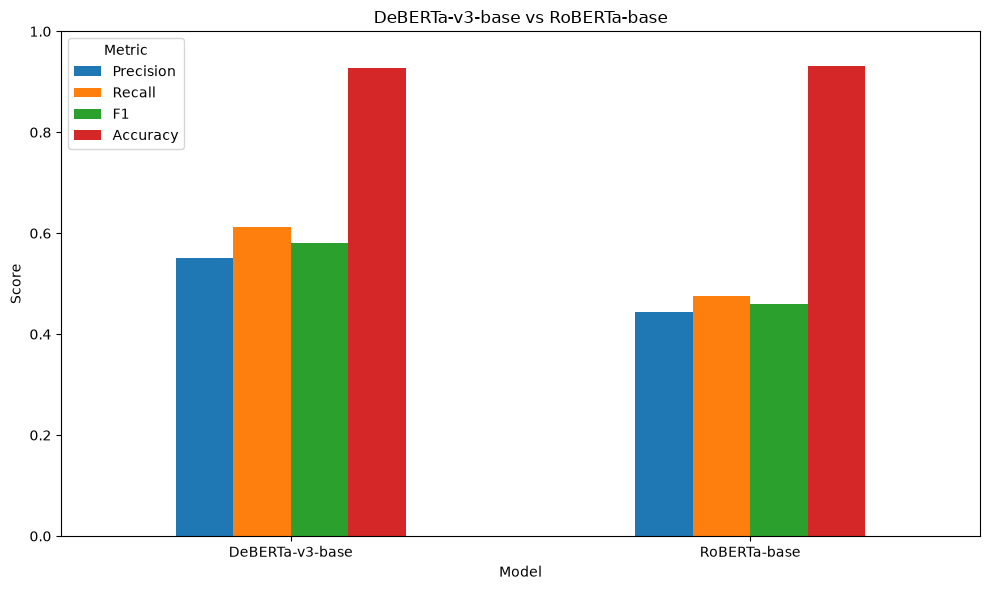

Saved: ../results\benchmark_overall_comparison.png


In [5]:
ax = overall_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("DeBERTa-v3-base vs RoBERTa-base")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

overall_chart_path = os.path.join(
    RESULTS_DIR,
    "benchmark_overall_comparison.png"
)

plt.savefig(overall_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", overall_chart_path)


## 5. Select the Winning Benchmark

The winning model is selected using **test F1-score** as the primary comparison metric.

Accuracy is still reported, but it is not used as the main selection criterion because NER datasets contain many non-entity (`O`) tokens. A model can therefore obtain high token accuracy even if its entity-recognition performance is weaker.


In [6]:
deberta_f1 = float(benchmark_a["test_f1"])
roberta_f1 = float(benchmark_b["overall"]["f1"])

if deberta_f1 > roberta_f1:
    winner = "DeBERTa-v3-base"
    winner_f1 = deberta_f1
elif roberta_f1 > deberta_f1:
    winner = "RoBERTa-base"
    winner_f1 = roberta_f1
else:
    winner = "Tie"
    winner_f1 = deberta_f1

print("WINNING BENCHMARK")
print("=" * 50)
print("Model:", winner)
print(f"F1-score: {winner_f1:.4f}")


WINNING BENCHMARK
Model: DeBERTa-v3-base
F1-score: 0.5797


## 6. Per-Entity F1 Comparison

In [7]:
# Load Benchmark A per-entity results if available
if os.path.exists(A_ENTITY_CSV):
    a_entity = pd.read_csv(A_ENTITY_CSV, index_col=0)

    # Keep only actual entity rows, excluding averages if present
    excluded_rows = {"micro avg", "macro avg", "weighted avg"}
    a_entity = a_entity[
        ~a_entity.index.astype(str).isin(excluded_rows)
    ]

    # Benchmark B per-entity results come from benchmark_b.json
    b_entity = pd.DataFrame(benchmark_b["per_entity"]).T

    common_entities = sorted(
        set(a_entity.index.astype(str))
        & set(b_entity.index.astype(str))
    )

    entity_comparison = pd.DataFrame({
        "Entity": common_entities,
        "DeBERTa F1": [
            float(a_entity.loc[e, "f1-score"])
            for e in common_entities
        ],
        "RoBERTa F1": [
            float(b_entity.loc[e, "f1-score"])
            for e in common_entities
        ]
    })

    entity_comparison["Difference"] = (
        entity_comparison["DeBERTa F1"]
        - entity_comparison["RoBERTa F1"]
    )

    entity_comparison["Better Model"] = entity_comparison.apply(
        lambda row: (
            "DeBERTa-v3-base"
            if row["DeBERTa F1"] > row["RoBERTa F1"]
            else (
                "RoBERTa-base"
                if row["RoBERTa F1"] > row["DeBERTa F1"]
                else "Tie"
            )
        ),
        axis=1
    )

    entity_comparison = entity_comparison.sort_values(
        "DeBERTa F1",
        ascending=False
    ).reset_index(drop=True)

    display(entity_comparison.round(4))

    entity_comparison.to_csv(
        os.path.join(
            RESULTS_DIR,
            "benchmark_per_entity_comparison.csv"
        ),
        index=False
    )

    print("Saved: ../results/benchmark_per_entity_comparison.csv")

else:
    entity_comparison = None
    print(
        "benchmark_a_per_entity.csv was not found. "
        "Overall comparison is still complete."
    )


,Entity,DeBERTa F1,RoBERTa F1,Difference,Better Model
0,NAME,0.9333,0.9362,-0.0028,RoBERTa-base
1,EMAIL,0.8205,0.3265,0.4940,DeBERTa-v3-base
2,DEGREE,0.7059,0.3571,0.3487,DeBERTa-v3-base
3,DESIGNATION,0.6087,0.5000,0.1087,DeBERTa-v3-base
4,LOCATION,0.5902,0.7097,-0.1195,RoBERTa-base
5,COMPANY,0.4600,0.3765,0.0835,DeBERTa-v3-base
6,SKILLS,0.3333,0.0000,0.3333,DeBERTa-v3-base
7,COLLEGE_NAME,0.3000,0.3889,-0.0889,RoBERTa-base
8,GRADUATION_YEAR,0.1538,0.0000,0.1538,DeBERTa-v3-base
9,YEARS_OF_EXPERIENCE,0.0000,0.0000,0.0000,Tie


Saved: ../results/benchmark_per_entity_comparison.csv


## 7. Per-Entity F1 Chart

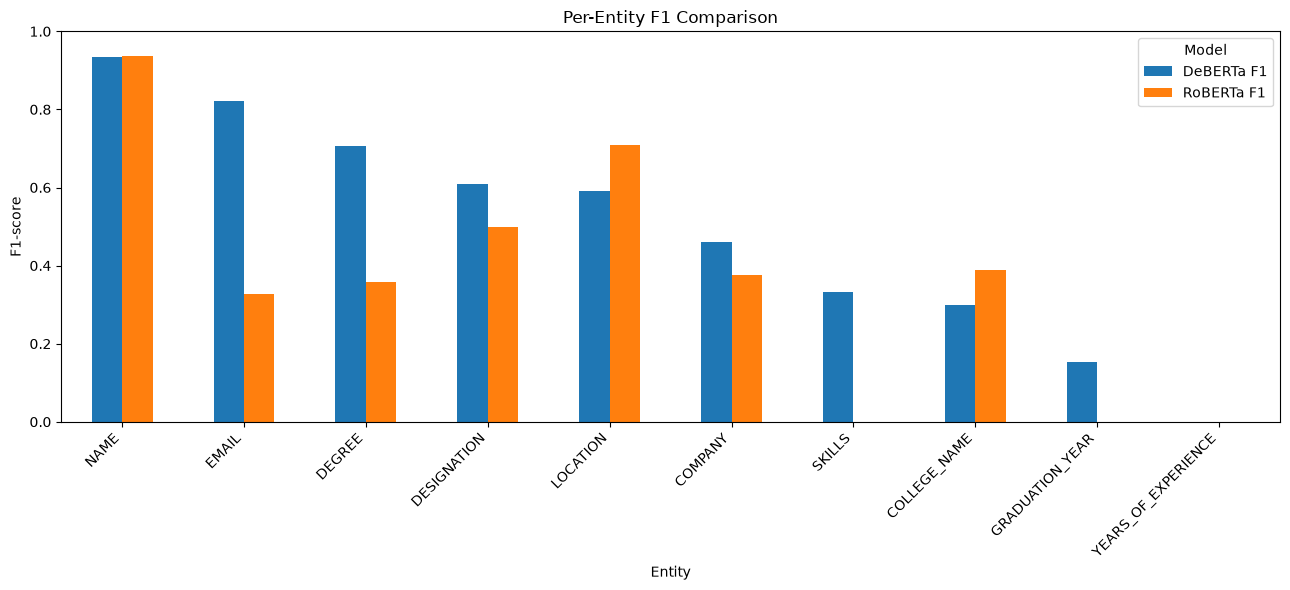

Saved: ../results\benchmark_per_entity_f1_comparison.png


In [8]:
if entity_comparison is not None and not entity_comparison.empty:

    plot_df = entity_comparison.set_index("Entity")[
        ["DeBERTa F1", "RoBERTa F1"]
    ]

    ax = plot_df.plot(
        kind="bar",
        figsize=(13, 6)
    )

    plt.title("Per-Entity F1 Comparison")
    plt.xlabel("Entity")
    plt.ylabel("F1-score")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Model")
    plt.tight_layout()

    entity_chart_path = os.path.join(
        RESULTS_DIR,
        "benchmark_per_entity_f1_comparison.png"
    )

    plt.savefig(entity_chart_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", entity_chart_path)


## 8. Benchmark Comparison Summary

In [9]:
a_precision = float(benchmark_a["test_precision"])
a_recall = float(benchmark_a["test_recall"])
a_f1 = float(benchmark_a["test_f1"])
a_accuracy = float(benchmark_a["test_accuracy"])

b_precision = float(benchmark_b["overall"]["precision"])
b_recall = float(benchmark_b["overall"]["recall"])
b_f1 = float(benchmark_b["overall"]["f1"])
b_accuracy = float(benchmark_b["overall"]["accuracy"])

print("BENCHMARK COMPARISON SUMMARY")
print("=" * 70)

print(
    f"DeBERTa-v3-base achieved Precision={a_precision:.4f}, "
    f"Recall={a_recall:.4f}, F1={a_f1:.4f}, "
    f"Accuracy={a_accuracy:.4f}."
)

print(
    f"RoBERTa-base achieved Precision={b_precision:.4f}, "
    f"Recall={b_recall:.4f}, F1={b_f1:.4f}, "
    f"Accuracy={b_accuracy:.4f}."
)

print()

if winner == "DeBERTa-v3-base":
    print(
        f"DeBERTa-v3-base is selected as the winning benchmark because "
        f"its F1-score ({a_f1:.4f}) is higher than RoBERTa-base "
        f"({b_f1:.4f})."
    )
elif winner == "RoBERTa-base":
    print(
        f"RoBERTa-base is selected as the winning benchmark because "
        f"its F1-score ({b_f1:.4f}) is higher than DeBERTa-v3-base "
        f"({a_f1:.4f})."
    )
else:
    print("Both models achieved the same F1-score.")


BENCHMARK COMPARISON SUMMARY
DeBERTa-v3-base achieved Precision=0.5505, Recall=0.6122, F1=0.5797, Accuracy=0.9271.
RoBERTa-base achieved Precision=0.4435, Recall=0.4753, F1=0.4589, Accuracy=0.9310.

DeBERTa-v3-base is selected as the winning benchmark because its F1-score (0.5797) is higher than RoBERTa-base (0.4589).


## 9. Interpretation

The benchmark comparison should be discussed primarily using **F1-score**, followed by precision and recall. Accuracy should be interpreted carefully because a large number of tokens in resume NER belong to the non-entity `O` class.

For the current results, **DeBERTa-v3-base is the stronger benchmark overall** because it achieves higher precision, recall, and F1-score than RoBERTa-base. RoBERTa-base has slightly higher accuracy, but the difference is small and does not outweigh its weaker entity-level precision, recall, and F1 performance.

## 10. Save Final Comparison Result

In [10]:
comparison_result = {
    "benchmark_a": {
        "model": benchmark_a["model"],
        "precision": float(benchmark_a["test_precision"]),
        "recall": float(benchmark_a["test_recall"]),
        "f1": float(benchmark_a["test_f1"]),
        "accuracy": float(benchmark_a["test_accuracy"])
    },
    "benchmark_b": {
        "model": benchmark_b["model"],
        "precision": float(benchmark_b["overall"]["precision"]),
        "recall": float(benchmark_b["overall"]["recall"]),
        "f1": float(benchmark_b["overall"]["f1"]),
        "accuracy": float(benchmark_b["overall"]["accuracy"])
    },
    "selection_metric": "F1",
    "winner": winner,
    "winner_f1": float(winner_f1)
}

comparison_json_path = os.path.join(
    RESULTS_DIR,
    "benchmark_comparison.json"
)

with open(
    comparison_json_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        comparison_result,
        f,
        indent=4
    )

print("Saved:", comparison_json_path)


Saved: ../results\benchmark_comparison.json


## Final Decision

**Selected benchmark for enhancement: DeBERTa-v3-base**

Current test results:

| Model | Precision | Recall | F1-score | Accuracy |
|---|---:|---:|---:|---:|
| DeBERTa-v3-base | 0.5505 | 0.6122 | **0.5797** | 0.9271 |
| RoBERTa-base | 0.4435 | 0.4753 | 0.4589 | **0.9310** |

DeBERTa-v3-base is selected because it provides the stronger entity-recognition performance, especially in terms of **F1-score, precision, and recall**.
